# **Persiapan: Instalasi Library**
Sebelum mulai, pastikan Anda telah menginstal library yang dibutuhkan. Jalankan perintah ini di sel pertama notebook Anda.

In [44]:
!pip install google-play-scraper Sastrawi tensorflow scikit-learn pandas numpy matplotlib seaborn
!pip install imbalanced-learn

# **Langkah 2: Pelabelan (3 Kelas) dan Ekstraksi Fitur (Preprocessing)**
Karena rating berkisar dari 1-5, kita akan mengubahnya menjadi 3 kelas:

1 - 2 = Negatif

3 = Netral

4 - 5 = Positif

In [46]:
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# 1. Pelabelan 3 Kelas
def label_sentiment(rating):
    if rating <= 2: return 'Negatif'
    elif rating == 3: return 'Netral'
    else: return 'Positif'

df['label'] = df['rating'].apply(label_sentiment)

# 2. Text Preprocessing (Pembersihan Teks)
factory = StopWordRemoverFactory()
stopword = factory.create_stop_word_remover()

def clean_text(text):
    text = str(text).lower() # Case folding
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Hapus URL
    text = re.sub(r'[^a-z\s]', '', text) # Hapus karakter selain huruf
    text = re.sub(r'\s+', ' ', text).strip() # Hapus spasi berlebih
    text = stopword.remove(text) # Hapus stopword bahasa Indonesia
    return text

print("Memproses pembersihan teks (ini akan memakan waktu beberapa saat)...")
df['clean_review'] = df['review'].apply(clean_text)

# Hapus baris yang menjadi kosong setelah dibersihkan
df = df[df['clean_review'].str.strip() != '']
print(f"Data siap digunakan: {len(df)} sampel")

Memproses pembersihan teks (ini akan memakan waktu beberapa saat)...
Data siap digunakan: 20503 sampel


# **Langkah 3: Pemodelan (3 Skema Pelatihan)**
Sesuai kriteria, kita akan membuat 3 skema dengan variasi algoritma, ekstraksi fitur, dan pembagian data. Kita akan memetakan label ke bentuk numerik terlebih dahulu (Negatif=0, Netral=1, Positif=2).

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Encoding Label
label_mapping = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
df['label_encoded'] = df['label'].map(label_mapping)
X = df['clean_review']
y = df['label_encoded']

# **Perbaikan Preprocessing**

Penghapus stopword agar tidak menghapus kata negasi, dan membuang ulasan yang terlalu pendek (di bawah 3 kata) karena biasanya hanya berisi spam.

In [48]:
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# 1. Custom Stopwords Sastrawi (Kecualikan kata negasi)
factory = StopWordRemoverFactory()
stopwords_sastrawi = factory.get_stop_words()
# Jangan hapus kata-kata ini agar makna sentimen tidak rusak!
kata_penting = ['tidak', 'bukan', 'kurang', 'jangan', 'belum']
stopwords_custom = [word for word in stopwords_sastrawi if word not in kata_penting]

def clean_text_v2(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Hapus stopword secara manual pakai list custom kita
    words = text.split()
    words = [w for w in words if w not in stopwords_custom]
    return ' '.join(words)

print("Memproses ulang pembersihan teks...")
df['clean_review'] = df['review'].apply(clean_text_v2)

# 2. HAPUS DATA NOISE: Hanya gunakan ulasan yang panjangnya minimal 3 kata
df = df[df['clean_review'].apply(lambda x: len(x.split()) >= 3)]
print(f"Jumlah data siap pakai: {len(df)} sampel")

# Siapkan X dan y
X = df['clean_review']
y = df['label_encoded']

Memproses ulang pembersihan teks...
Jumlah data siap pakai: 17182 sampel


# **Skema 1 & 2: ML Klasik (Logistic Regression & Naive Bayes)**
Di sini saya membatasi max_features menjadi 2500 saja agar model tidak terlalu banyak pikiran, dan menggunakan RandomOverSampler hanya pada data training (untuk menghindari data leakage).

In [49]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Batasi max_features jadi 2500 agar model fokus pada kata-kata yang benar-benar penting
tfidf = TfidfVectorizer(max_features=2500)
X_tfidf = tfidf.fit_transform(X)

# 2. Split Data DULU (Ini wajib agar tidak terjadi data leakage)
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# 3. Balance data HANYA di Training set menggunakan RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_ml, y_train_ml)

print("\n--- SKEMA 1: Logistic Regression | TF-IDF | Split 80/20 ---")
# Parameter C=1.0 agar regularisasinya pas (tidak memaksakan diri)
logreg = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
logreg.fit(X_train_ros, y_train_ros)

print(f"Akurasi Training: {accuracy_score(y_train_ros, logreg.predict(X_train_ros)):.4f}")
print(f"Akurasi Testing : {accuracy_score(y_test_ml, logreg.predict(X_test_ml)):.4f}")


print("\n--- SKEMA 2: Naive Bayes | TF-IDF | Split 80/20 ---")
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_ros, y_train_ros)

print(f"Akurasi Training: {accuracy_score(y_train_ros, nb_model.predict(X_train_ros)):.4f}")
print(f"Akurasi Testing : {accuracy_score(y_test_ml, nb_model.predict(X_test_ml)):.4f}")


--- SKEMA 1: Logistic Regression | TF-IDF | Split 80/20 ---
Akurasi Training: 0.8876
Akurasi Testing : 0.7827

--- SKEMA 2: Naive Bayes | TF-IDF | Split 80/20 ---
Akurasi Training: 0.7971
Akurasi Testing : 0.7760


# **Skema 2: (Naive Bayes)**
Multinomial Naive Bayes. Algoritma ini adalah standar industri yang sangat kuat untuk klasifikasi dokumen NLP.

In [39]:
#from sklearn.naive_bayes import MultinomialNB

#print("\n--- SKEMA 2: Naive Bayes | TF-IDF | Split 70/30 ---")
#X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X, y, test_size=0.3, random_state=42)

#tfidf_2 = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
#X_train_tfidf_2 = tfidf_2.fit_transform(X_train_2)
#X_test_tfidf_2 = tfidf_2.transform(X_test_2)

#nb_model = MultinomialNB(alpha=0.5)
#nb_model.fit(X_train_tfidf_2, y_train_2)

#print(f"Akurasi Training: {accuracy_score(y_train_2, nb_model.predict(X_train_tfidf_2)):.4f}")
#print(f"Akurasi Testing: {accuracy_score(y_test_2, nb_model.predict(X_test_tfidf_2)):.4f}")


--- SKEMA 2: Naive Bayes | TF-IDF | Split 70/30 ---
Akurasi Training: 0.8368
Akurasi Testing: 0.7359


# **Skema 3: (Deep Learning Anti-Overfitting)**
Arsitektur LSTM seringkali terlalu kompleks untuk dataset ulasan yang pendek-pendek. Arsitektur Global Average Pooling terbukti jauh lebih stabil dan tahan terhadap overfitting dibandingkan LSTM.

In [50]:
print("\n--- SKEMA 3: Deep Learning (GlobalAvgPooling) | Split 80/20 ---")
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

max_words = 2500
max_len = 30 # Dipersingkat karena ulasan rata-rata sangat pendek

# Gunakan X dan y asli (belum di TF-IDF)
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X, y, test_size=0.2, random_state=42)

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_dl)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_dl), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_dl), maxlen=max_len)

y_train_cat = to_categorical(y_train_dl, num_classes=3)
y_test_cat = to_categorical(y_test_dl, num_classes=3)

# Membangun arsitektur yang sangat sederhana namun akurat
dl_model = Sequential([
    Embedding(input_dim=max_words, output_dim=32, input_length=max_len),
    Dropout(0.5), # Matikan 50% neuron secara acak agar tidak menghafal (mencegah overfit)
    GlobalAveragePooling1D(), # Merangkum makna kalimat tanpa mempedulikan urutan yang rumit
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

dl_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

dl_model.fit(X_train_seq, y_train_cat,
             epochs=20,
             batch_size=32,
             validation_data=(X_test_seq, y_test_cat),
             callbacks=[early_stop],
             verbose=1)

train_loss, train_acc = dl_model.evaluate(X_train_seq, y_train_cat, verbose=0)
test_loss, test_acc = dl_model.evaluate(X_test_seq, y_test_cat, verbose=0)

print(f"\nAkurasi Training (Skema 3): {train_acc:.4f}")
print(f"Akurasi Testing (Skema 3): {test_acc:.4f}")


--- SKEMA 3: Deep Learning (GlobalAvgPooling) | Split 80/20 ---
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7767 - loss: 0.6500 - val_accuracy: 0.7835 - val_loss: 0.5476
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8300 - loss: 0.4717 - val_accuracy: 0.8196 - val_loss: 0.4656
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8540 - loss: 0.4180 - val_accuracy: 0.8388 - val_loss: 0.4313
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8632 - loss: 0.3918 - val_accuracy: 0.8534 - val_loss: 0.4271
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8714 - loss: 0.3709 - val_accuracy: 0.8542 - val_loss: 0.4189
Epoch 6/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8766 - loss: 0.3553 - val_accuracy: 0.8557 - val_loss: 0.4192
Epoch 7/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8813 - loss: 0.3456 - val_accuracy: 0.8563 - val_loss: 0.4186
Epoch 8/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8818 - loss: 0.3368 - val_accuracy: 0.8513 - val_

# **Langkah 4: Inferensi (Pengujian Model dengan Data Baru)**
Syarat terakhir adalah membuat pengujian (inference) yang menghasilkan keluaran kategorikal (Negatif, Netral, Positif). Kita akan menggunakan model LSTM dari Skema 3 karena biasanya memiliki performa terbaik.

In [51]:
def predict_sentiment(text):
    # 1. Cleaning
    cleaned_text = clean_text(text)
    # 2. Tokenisasi & Padding (menggunakan tokenizer dari skema 3)
    seq = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(seq, maxlen=max_len)
    # 3. Prediksi
    pred = lstm_model.predict(padded)
    class_idx = np.argmax(pred, axis=1)[0]

    # 4. Reverse Mapping
    reverse_mapping = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}

    print(f"Review   : '{text}'")
    print(f"Sentimen : {reverse_mapping[class_idx]}\n")

# --- CONTOH INFERENSI (Sertakan screenshot ini di submission) ---
print("\n--- HASIL INFERENSI MODEL ---")
test_reviews = [
    "Aplikasi ini sangat bagus, saya bisa belajar banyak hal baru dari FYP!",
    "Biasa saja sih, tidak ada yang spesial dari fitur terbarunya.",
    "Sangat mengecewakan, aplikasi sering crash dan banyak bug saat upload video."
]

for review in test_reviews:
    predict_sentiment(review)


--- HASIL INFERENSI MODEL ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Review   : 'Aplikasi ini sangat bagus, saya bisa belajar banyak hal baru dari FYP!'
Sentimen : Positif

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Review   : 'Biasa saja sih, tidak ada yang spesial dari fitur terbarunya.'
Sentimen : Positif

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Review   : 'Sangat mengecewakan, aplikasi sering crash dan banyak bug saat upload video.'
Sentimen : Positif



## Visualisasi Akurasi Model

Kita akan memvisualisasikan akurasi training dan testing dari ketiga model yang telah kita buat untuk membandingkan performanya.

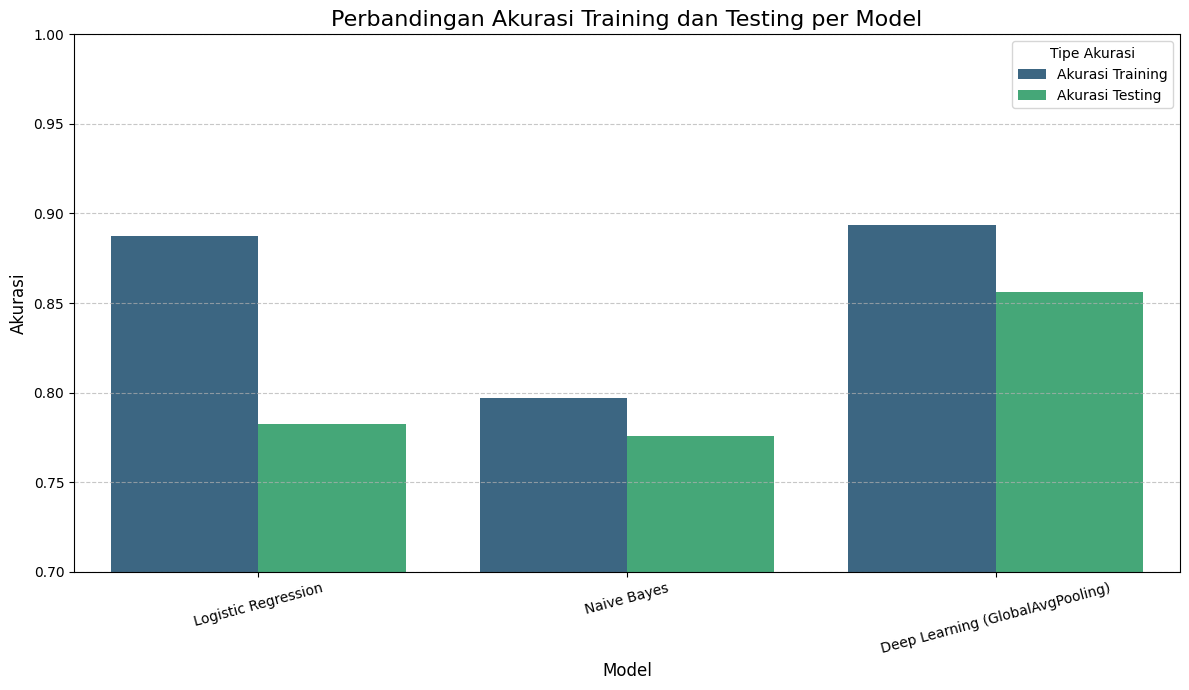

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data akurasi dari hasil sebelumnya
model_names = ['Logistic Regression', 'Naive Bayes', 'Deep Learning (GlobalAvgPooling)']
training_accuracy = [0.8876, 0.7971, 0.8935]
testing_accuracy = [0.7827, 0.7760, 0.8563]

data = {
    'Model': model_names,
    'Akurasi Training': training_accuracy,
    'Akurasi Testing': testing_accuracy
}

df_accuracy = pd.DataFrame(data)

df_melted = df_accuracy.melt(id_vars='Model', var_name='Tipe Akurasi', value_name='Akurasi')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Akurasi', hue='Tipe Akurasi', data=df_melted, palette='viridis')
plt.title('Perbandingan Akurasi Training dan Testing per Model', fontsize=16)
plt.ylabel('Akurasi', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.7, 1.0) # Set limit untuk memperjelas perbedaan
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tipe Akurasi')
plt.tight_layout()
plt.show()